# Logistic Regression

In [1]:
# importiamo i pacchetti necessari
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from  sklearn.linear_model import LogisticRegressionCV
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit

%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../..')

import src.class_funcs as fs

from IPython.display import Image, display

In [2]:
# scelta del seed random per la riproducibilità dei risultati
seed = 58327419

## Studio binario

Tramite questo studio di classificazione vogliamo essere in grado di effettuare previsioni sull'inquinamento dell'aria.\
Per sfruttare al massimo le conoscenze sviluppate in classe, scriviamo inizialmente il problema come un preblema di carattere binario. In particolare, etichettiamo come 1 = 'ok' tutti i punti con EAQI 'good' o 'fair' (AQI < 40), mentre chiamiamo 0 = 'not ok' i restanti punti con EAQI 'moderate', 'poor' o 'very poor'. Data una certa ora, cerchiamo quindi di prevedere se la qualità dell'aria sarà 'ok' o 'not ok' sulla base delle rilevazioni nelle ore a questa precedenti.

Costruiamo quindi il dataframe inserendo le ore precedenti a quella di target come specificato sopra.

Seppure la colonna 'winds_spd' sia molto correlata con gli inquinanti, contenendo diversi NaN, scegliamo per il momento di escluderla. L'influenza di questa feature sulle previsioni è approfondita nel notebook di appendice.

In [3]:
binary_class_df = pd.read_csv('../../data/processed/dataset_binary_class_processed.csv')

# togliamo la colonna 'winds_spd'
binary_class_df.drop('winds_spd', axis=1, inplace=True)

binary_class_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,1
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,1
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,1
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,1
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,1


### Discussione time-series dataset
Il nostro dataset di riferimento non è fatto di punti indipendenti, ma ordinati temporalmente. Per questo motivo utilizzare i metodi standard visti in classe creerebbe diversi data leakage più o meno importanti.
Tenendo conto di questa osservazione apportiamo le seguenti modifiche:
- Suddividiamo cronologicamente il dataset in train, valid e test: per fare in modo che il modello non colga informazioni dal futuro, scegliamo di ordinare nel tempo le tre sezioni in cui dividiamo il dataset.
- Al posto di usare la cross-validation standard, utilizziamo la cross-validation implementata in TimeSeriesSplit ("cross-validation on a rolling basis")

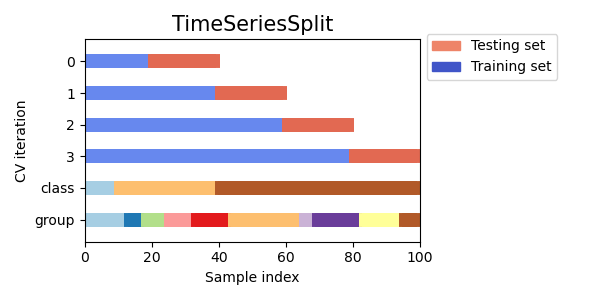

In [4]:
# per rendere più chiaro quello che stiamo facendo, riportiamo l'immagine trovata sul sito di sickit-learn
display(Image(filename='../../images/sphx_glr_plot_cv_indices_013.png'))

### Pipeline
Dato che la procedura standardizzazione-fit/predict verrà usata molto, vogliamo provare ad automatizzare questo processo usando una pipeline. Nella pipeline vogliamo fare in modo che vengano standardizzate solo alcune colonne e non altre.

La pipeline è particolarmente appropriata nel nostro caso perché, usando la cross validation autoimplementata in sickit-learn, la pipeline riscala il train ad ogni iterazione del k-fold, per cui si evita leakage interno al train.

In [5]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in binary_class_df.columns if col.startswith('station_')]
num_features = binary_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_binary = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_binary = LogisticRegressionCV(
    Cs=10,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                             # per la riproducibilità dei risultati
    use_legacy_attributes=False)

# costruiamo la nostra pipeline vera e propria
model_binary = Pipeline(steps=[('preprocessor', preprocessor_binary),('classifier', classifier_binary)])

### Train, Valid, Test split + fit
Dividiamo quindi il dataset in train (70%), valid (15%) e test (15%). Utilizziamo la cross-validation k-fold già implementata in LogisticRegressionCV. Introduciamo valid come insieme su cui scegliere il threshold più adatto per la logistic regression. Dopo aver scelto quest'ultimo, rialleniamo il modello su train + valid e lo testiamo su test.

In [6]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
bi_X_train, bi_X_valid, bi_X_test, bi_y_train, bi_y_valid, bi_y_test = fs.get_train_valid_test(binary_class_df, 0.7, 0.15, feature_cols)

In [7]:
# alleniamo il modello sul nostro insieme di training
model_binary.fit(bi_X_train,bi_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

### Studio importanza features
Quali sono le features più importanti?

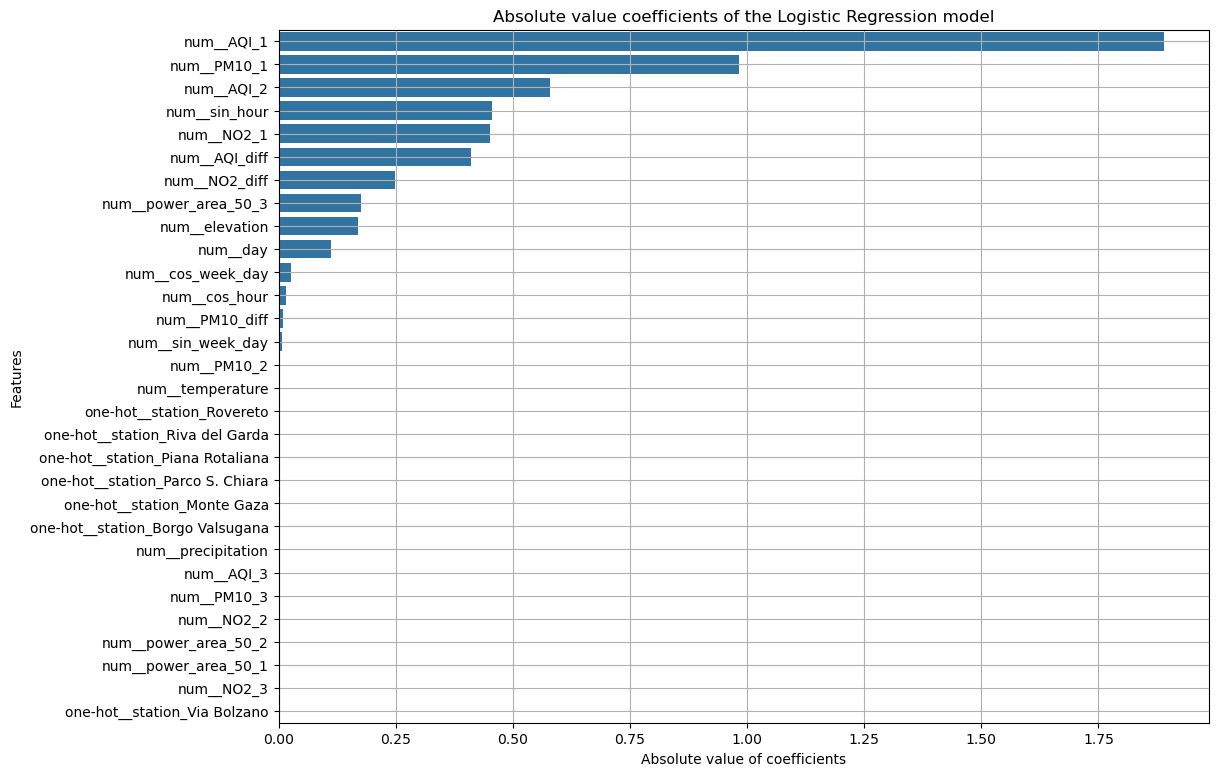

In [8]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = model_binary.named_steps['preprocessor'].get_feature_names_out()

# rappresento il valore assoluto dei coefficienti
fs.display_abs_coefs(model_binary.named_steps['classifier'],feature_names)

Come ci potevamo aspettare, le feature più importanti sono quelle con le indicazioni sugli inquinanti nelle ore precedenti quella in studio. In mezzo a questi si inserisce il ciclo giornaliero, che, come visto nell'EDA, ha delle fluttuazioni caratteristiche e rilevanti.

Feature rilevante è anche il dato sui consumi elettrici tre ore prima dell'ora in studio. Particolarmente interessante è proprio il fatto che il dato rilevante sia quello di tre ore prima. Come visto nell'EDA, la correlazione tra inquinanti e consumi aumenta leggermente aumentando il delay, nelle prime ore. Colleghiamo a questo fenomeno il motivo del risultato. Sospettiamo che le altre features sui consumi elettrici siano molto meno rilevanti perché portano informazioni ridondanti e sono pertanto soppresse dal regolarizzatore elasticnet.

Interessante è anche il fatto che le stazioni non sembrino particolarmente rilevanti nello studio. I dati delle stazioni divergono significativamente solo in una seconda parte del periodo in studio. Pensiamo pertanto che la differenza tra le stazioni sia poco rappresentata nell'insieme di training, che fa riferimento prevalentemente alla prima parte del periodo.

Stranamente i dati meteo sono veramente poco rilevanti. Ci saremmo aspettati una dipendenza maggiore, ma probabilmente la scala temporale del problema rende poco visibili al classificatore questi trend.

### Studio matrici di confusione
Studiamo quindi le matrici di confusione per train e valid, capiamo come si comporti il nostro modello ed indaghiamo un eventuale overfitting.

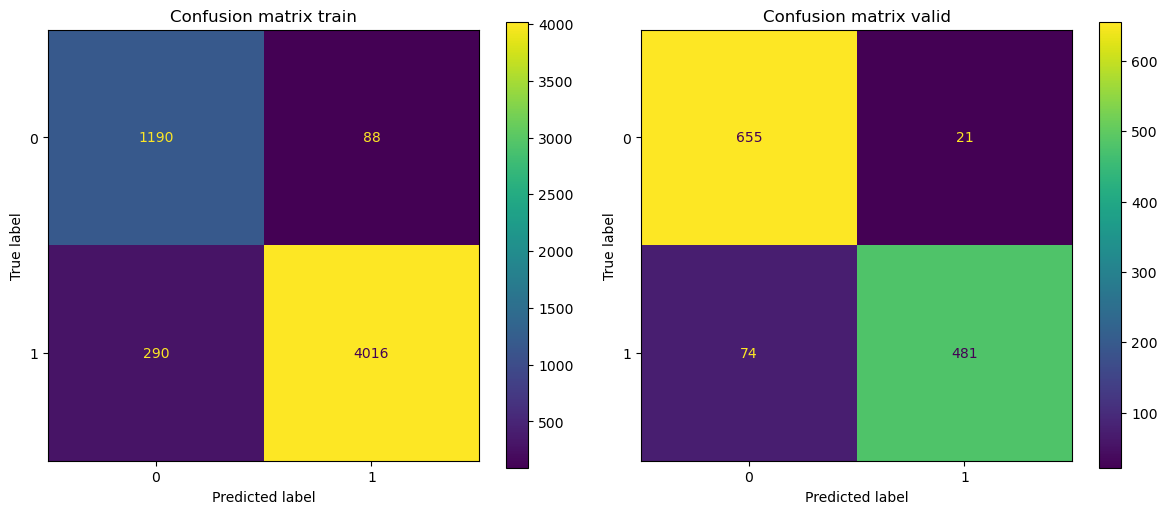

Performance del modello su train
Accuratezza:    0.93231
Precisione:     0.97856
Recall:         0.93265
F1 score:       0.95505
MCC:            0.82220
---------------------------------------------
Performance del modello su valid
Accuratezza:    0.92283
Precisione:     0.95817
Recall:         0.86667
F1 score:       0.91012
MCC:            0.84606


In [9]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix train', bi_X_train, bi_y_train, 'Confusion matrix valid', bi_X_valid, bi_y_valid)

print('Performance del modello su train')
fs.get_performance_param(model_binary, bi_X_train, bi_y_train)
print('---------------------------------------------')
print('Performance del modello su valid')
fs.get_performance_param(model_binary, bi_X_valid, bi_y_valid)

Non si assiste ad una significativa perdita di performance del modello tra train e valid, anzi, l'MCC migliora. Assumiamo quindi che il nostro modello generalizzi bene su dati nuovi ed escludiamo un possibile overfitting.

Una cosa da tenere a mente e che è particolarmente evidente nelle confusion matrix è il progressivo peggioramento della qualità dell'aria avvicinandosi a Natale. Avendo a disposizione un intervallo di tempo così limitato, questo risulta in un insieme di train abbastanza diverso da quello di valid e test, con questi ultimi due che avrenno una frazione di 'not ok' molto maggiore rispetto al train.
Sempre guardando l'andamento temporale della qualità dell'aria, ci possiamo aspettare che la performance sul test sarà migliore di quella sul valid, visto che quest'ultimo comprende anche i giorni successivi al Natale e quindi risulta più simile al train.

Detto ciò, anche guardando i parametri di performance, sembra che per una semplice logistic regression il modello funzioni piuttosto bene.

Proviamo a migliorare l'MCC scegliendo il miglior threshold su valid nella prossima sezione.

### Ottimizzazione del threshold
Avendo delle classi molto sbilanciate, siamo interessati ad ottimizzare il threshold utilizzando l'MCC come parametro da massimizzare.

Anche sapendo questo, può essere interessante ed educativo passare prima attraverso la curva ROC e Precision-Recall. Inoltre, vogliamo valutare anche metodi diversi per scegliere il miglior threshold.

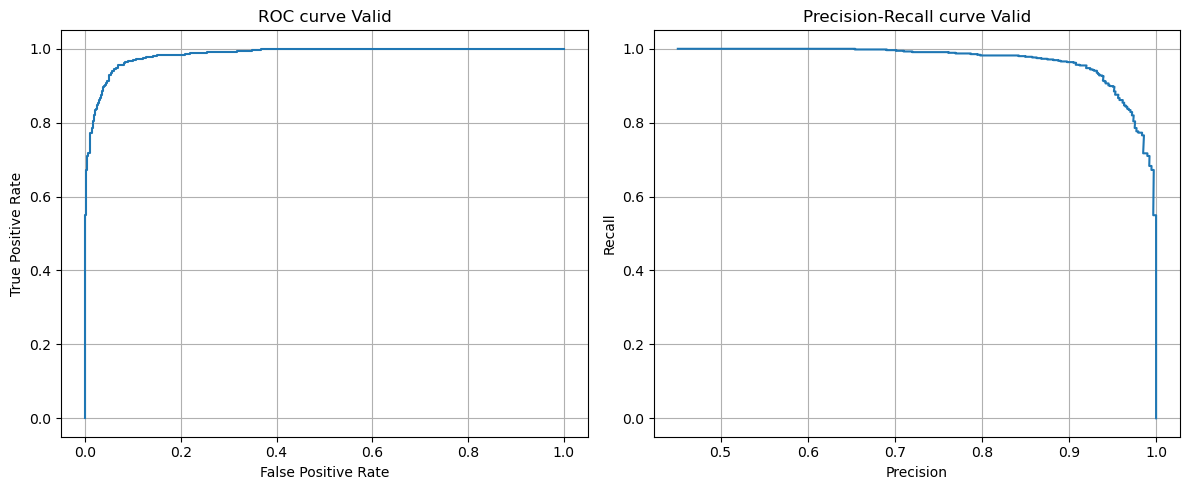

In [10]:
# disegnamo la curva ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1] # restituisce le predizioni in forma di probabilità, quindi permette di disegnare la ROC

# parametri per la curva ROC
fpr,tpr,thr = metrics.roc_curve(bi_y_valid,y_proba_va)

ax0 = axes[0]
ax0.plot(fpr, tpr)
ax0.set_xlabel('False Positive Rate')
ax0.set_ylabel('True Positive Rate')
ax0.set_title('ROC curve Valid')
ax0.grid()

# parametri per la curva Precision-Recall
prec,rec,thr = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

ax1 = axes[1]
ax1.plot(prec, rec)
ax1.set_xlabel('Precision')
ax1.set_ylabel('Recall')
ax1.set_title('Precision-Recall curve Valid')
ax1.grid()

plt.tight_layout()

Come aspettato, vista la performance abbastanza buona del modello, la curva ROC è molto lontana dalla diagonale (molto poco casuale) e anche la curva Precision-Recall è piuttosto spostata verso l'angolo in alto a destra, per cui possiamo avere valori alti di intrambe le metriche contemporaneamente.

Rappresentiamo anche le curve Precision e Recall separate in funzione del threshold.

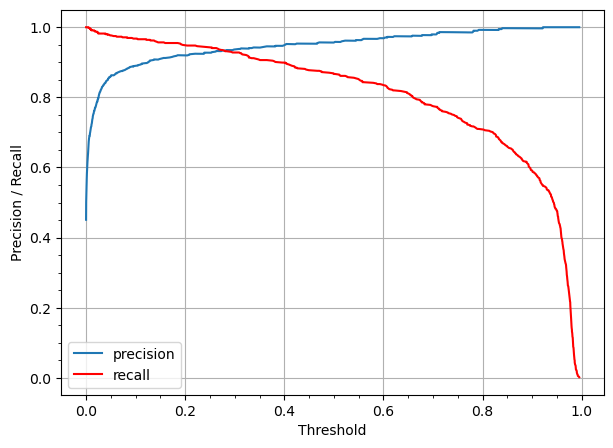

In [11]:
fig, ax = plt.subplots(1,1,figsize=(7,5))

ax.plot(thr, prec[:-1], label='precision')
ax.plot(thr, rec[:-1],label='recall',color='red')
ax.set_xlabel('Threshold')
ax.set_ylabel('Precision / Recall')
ax.minorticks_on()
ax.legend()
ax.grid(visible= True)

Come aspettato, la precision = TP / PP aumenta all'aumentare del threshold, andando a 1 per il threshold che diventa 1:\
per thr -> 1, TP -> 0 e PP -> 0 => prec -> 1, per thr -> 0, TP -> AP e PP -> n => prec -> AP / n, è ≠ 0.5 se le classi sono sbilanciate

Al contrario, il recall = TP / AP diminuisce all'aumentare del threshold:\
per thr -> 1, TP -> 0 e AP = const => rec -> 0, per thr -> 0, TP -> AP => rec -> 1

Possiamo scegliere il threshold in diversi modi:
1. non volendo assegnare costi diversi ad una classe rispetto all'altra, una retta a pari performance (cioè a pari costo) nel grafico della ROC è una retta con coefficiente angolare P(N) / P(P) = #N / #P. In questa ottica, il threshold migliore è quindi il threshold che massimizza l'intercetta di questa retta (punto in cui la retta è tangente);

2. guardando online, un altro metro di scelta basato sulla ROC è la statistica J di Youden (si veda https://en.wikipedia.org/wiki/Youden%27s_J_statistic). In pratica il punto con migliore threshold è il punto che massimizza il valore J = sensitivity + specificity - 1 = TPR - FPR;

3. si può scegliere il threshold come punto di intersezione tra Precision e Recall. In questo modo non preferiamo una curva all'altra;

4. studiando il F1-score, si può scegliere il threshold che massimizza questo parametro, anche se questo è più adatto ai contesti in cui ci interessano particolarmente i positivi;

5. studiando il Matthews Correlation Coefficient (MCC), si può scegliere il threshold che massimizza questo parametro. In generale, questo parametro è particolarmente adatto allo studio di classi sbilanciate, che è proprio il nostro caso.

Dopo aver comparato sull'insieme di validazione i diversi threshold ottenuti in questo modo, rialleniamo il modello e passiamo finalmente alla valutazione della predittività del modello sull'insieme di test.

In [12]:
y_proba_va = model_binary.predict_proba(bi_X_valid)[:, 1]

# 1. Intercetta
num_P = bi_y_valid.sum()
num_N = len(bi_y_valid) - num_P

fpr,tpr,thr_roc = metrics.roc_curve(bi_y_valid,y_proba_va)

mx = (num_N /num_P) * fpr
intercept = tpr[:-1] - mx[:-1]

best_idx = np.argmax(intercept)
best_thr_int = thr_roc[best_idx]

# 2. statistica J di Youden
J_score = tpr[:-1] - fpr[:-1]

best_idx = np.argmax(J_score)
best_thr_J = thr_roc[best_idx]

# 3. intersezione Precision-Recall
prec,rec,thr_pre = metrics.precision_recall_curve(bi_y_valid,y_proba_va)

best_idx = np.argmin(np.abs(prec[:-1] - rec[:-1]))
best_thr_PR = thr_pre[best_idx]

# 4. F1-score
f1_score = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1])
best_idx = np.argmax(f1_score)
best_thr_f1 = thr_pre[best_idx]

thr = np.linspace(0, 1, int(1e3))

# 5. MCC
max_MCC_score = -1
best_thr_MCC = None

for t in thr:
    y_pred = (y_proba_va >= t).astype(int)
    MCC_score = metrics.matthews_corrcoef(bi_y_valid, y_pred)

    if (MCC_score > max_MCC_score):
        max_MCC_score = MCC_score
        best_thr_MCC = t

print(f'Threshold metodo intercetta:                {best_thr_int:.5f}')
print(f'Threshold statistica J di Youden:           {best_thr_J:.5f}')
print(f'Threshold intersezione Precision-Recall:    {best_thr_PR:.5f}')
print(f'Threshold F1-score:                         {best_thr_f1:.5f}')
print(f'Threshold MCC:                              {best_thr_MCC:.5f}')

Threshold metodo intercetta:                0.26280
Threshold statistica J di Youden:           0.18474
Threshold intersezione Precision-Recall:    0.27922
Threshold F1-score:                         0.18474
Threshold MCC:                              0.18318


È interessante notare come tutti i threshold calcolati siano piuttosto simili. Questo è positivo, perché suggerisce che la nostra scelta del threshold con MCC produca buoni risultati anche per le altre misure della performance del modello.

Passiamo quindi al retrain su Train + Valid e al test su Test.

### Retrain su train + valid e studio di test

In [13]:
# uniamo train e valid
bi_X_train_valid = pd.concat([bi_X_train, bi_X_valid], ignore_index=True)
bi_y_train_valid = pd.concat([bi_y_train, bi_y_valid], ignore_index=True)

# alleniamo il modello
model_binary.fit(bi_X_train_valid,bi_y_train_valid)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

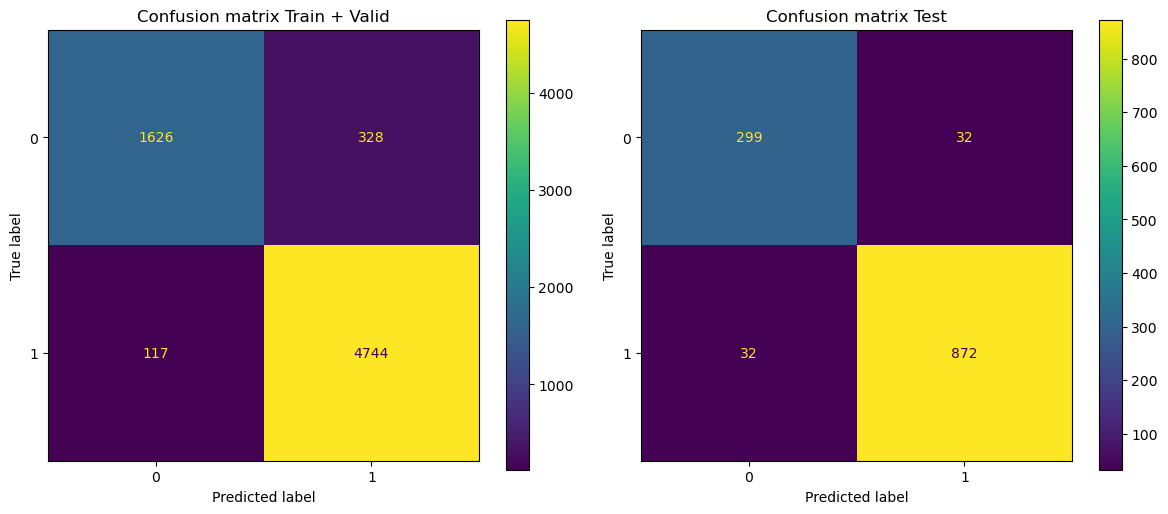

Performance del modello su Train + Valid
Accuratezza:    0.93470
Precisione:     0.93533
Recall:         0.97593
F1 score:       0.95520
MCC:            0.83760
---------------------------------------------
Performance del modello su Test
Accuratezza:    0.94818
Precisione:     0.96460
Recall:         0.96460
F1 score:       0.96460
MCC:            0.86793


In [14]:
fs.display_confusion_matrix(model_binary, 'Confusion matrix Train + Valid', bi_X_train_valid, bi_y_train_valid, 'Confusion matrix Test', bi_X_test, bi_y_test, best_thr_MCC)

print('Performance del modello su Train + Valid')
fs.get_performance_param(model_binary, bi_X_train_valid, bi_y_train_valid,thr=best_thr_MCC)
print('---------------------------------------------')
print('Performance del modello su Test')
fs.get_performance_param(model_binary, bi_X_test, bi_y_test,thr=best_thr_MCC)

Come previsto, il risultato sul test è molto migliore di quanto non fosse per il valid. Questo è sicuramente dovuto, almeno in parte, dalla scelta del threshold ottimale, con un contributo che viene sicuramente anche dall'allenamento su un insieme di cardinalità maggiore e più rappresentativo.

In generale, anche guardando i parametri di performance, possiamo ritenere il modello sufficientemente predittivo per una semplice logistic regression. Sicuramente l'intervallo di tempo così limitato e la variazione del trend degli inquinanti nel tempo non aiutano all'allenamento di un modello particolarmente efficace.

Successivamente proveremo a riaffrontare il problema usando la Random Forest, che ci aspettiamo riesca a produrre risultati migliori.

Passiamo quindi a discutere brevemente il problema multiclasse in cui consideriamo tutte le classi dell'EAQI. In generale, ci aspettiamo risultati peggiori rispetto a quelli dello studio binario, ma vogliamo comunque capire se sia possibile ottenere dei risultati buoni.

## Classificazione a 5 classi

In [15]:
# cominciamo importando il dataframe precedentemente preparato
multiclass_df = pd.read_csv('../../data/processed/dataset_multiclass_processed.csv')

# come fatto per il problema binario togliamo la colonna 'winds_spd'
multiclass_df.drop('winds_spd', axis=1, inplace=True)

multiclass_df.head()

,station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Piana Rotaliana,station_Riva del Garda,station_Rovereto,station_Via Bolzano,elevation,day,cos_week_day,...,PM10_3,NO2_3,AQI_3,power_area_50_3,temperature,precipitation,PM10_diff,NO2_diff,AQI_diff,target
0,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,19.0,24.0,17.861264,10.950,0.0,1.0,1.0,4.0,fair
1,1,0,0,0,0,0,0,410,1,-0.900969,...,20.0,17.0,22.0,14.669913,11.000,0.0,-2.0,-2.0,0.0,fair
2,1,0,0,0,0,0,0,410,1,-0.900969,...,21.0,18.0,26.0,16.969367,10.925,0.0,5.0,0.0,6.0,fair
3,1,0,0,0,0,0,0,410,1,-0.900969,...,19.0,16.0,26.0,15.329278,10.950,0.0,-5.0,-1.0,-10.0,fair
4,1,0,0,0,0,0,0,410,1,-0.900969,...,24.0,16.0,32.0,17.519438,11.550,0.0,3.0,0.0,2.0,fair


In [16]:
# contiamo al volo il numeo di punti per ciascuna classe
multiclass_df['target'].value_counts()

target
good         2908
fair         2857
poor         1336
moderate      795
very poor     154
Name: count, dtype: int64

Notiamo come le classi sono profondamente sbilanciate. In particolare la cardinalità di 'very poor' è molto minore rispetto a tutte le altre classi ed immaginiamo sarà particolarmente concentrata verso metà dicembre. Teniamo a mente questo per la fase di validazione del modello.

### Pipeline
Provando ad allenare il modello multiclasse con 'saga', l'elasticnet e gli stessi parametri di prima, notiamo che nessun modello allenato raggiunge la convergenza entro 10000 iterazioni. Per evitare che l'allenamento sia troppo costoso, proviamo a cambiare il solver e rinunciamo all'elasticnet per lo studio.

In particolare passiamo al solver 'lbfgs', che dovrebbe essere più rapido a convergere, ma che supporta solo il regolarizzatore di Ridge. Visto che stiamo cedendo sull'elasticnet, aumentiamo a 20 il numero di lambda da testare.

In [17]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in multiclass_df.columns if col.startswith('station_')]
num_features = multiclass_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_multiclass = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_multiclass = LogisticRegressionCV(
    Cs=20,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='lbfgs',                                                 # scegliamo lbfgs
    l1_ratios=[0.0],                                                # alleniamo due modelli, rispettivamente con l2 e l1
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs = -1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                              # per la riproducibilità dei risultati
    use_legacy_attributes=False                                     # uso per evitare warning
)

# costruiamo la nostra pipeline vera e propria
model_multiclass = Pipeline(steps=[('preprocessor', preprocessor_multiclass),('classifier', classifier_multiclass)])

### Train, Test split
Per il caso dello studio multiclasse, la scelta del threshold sarebbe particolarmente pesante visto che andrebbero scelti molteplici threshold. Pertanto dividiamo solo in train e test e studiamo il modello. Scegliamo di dare al train l'80% dei dati ed al test il restante 20%.

In [ ]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
mc_X_train,_, mc_X_test, mc_y_train, _, mc_y_test = fs.get_train_valid_test(multiclass_df, 0.8, 0.0, feature_cols)

In [19]:
model_multiclass.fit(mc_X_train,mc_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

Vediamo quanto bene prevede il nostro modello.

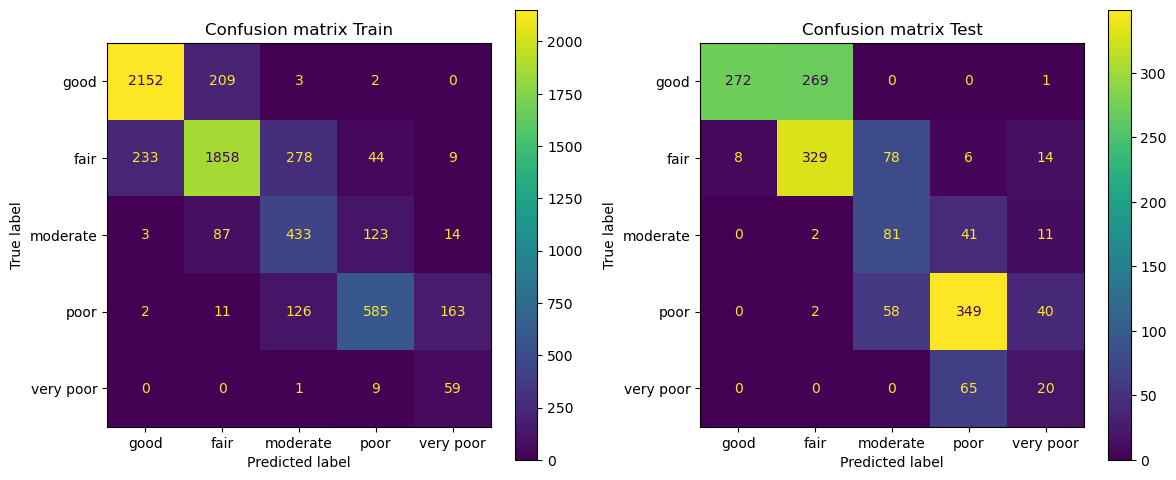

Performance del modello su Train
Accuratezza:    0.79435
Precisione:     0.81909
Recall:         0.79435
F1 score:       0.80245
MCC:            0.70969
---------------------------------------------
Performance del modello su Test
Accuratezza:    0.63852
Precisione:     0.71344
Recall:         0.63852
F1 score:       0.64467
MCC:            0.53626


In [20]:
class_order = ['good', 'fair', 'moderate', 'poor', 'very poor']

fs.display_confusion_matrix_multiclass(model_multiclass, class_order, 'Confusion matrix Train', mc_X_train, mc_y_train, title2='Confusion matrix Test', X2=mc_X_test, y2=mc_y_test)

print('Performance del modello su Train')
fs.get_performance_param(model_multiclass, mc_X_train, mc_y_train, binary=False)
print('---------------------------------------------')
print('Performance del modello su Test')
fs.get_performance_param(model_multiclass, mc_X_test, mc_y_test, binary=False)

Sia dalla confusion matrix, che dai parametri di performance sembra che il nostro modello non sia molto predittivo.\
La classe 'very poor' viene predetta male più volte di quanto non venga predetta bene e, in particolare, quelle volte che viene predetta male, dembra venga scambiata con la classe 'poor'. Lo stesso avviene anche per 'good', anche se il risultato è comunque migliore rispetto a 'very poor'.

Notiamo che le classificazioni sbagliate avvengono principalmente tra classi adiacenti e quindi la performance del modello è leggermente migliore rispetto a quanto possa apparire dai valori dei parametri. L'MCC, l'accuratezza e le altre misure, infatti, non hanno conoscenza delle distanze relative tra le classi ma tengono unicamente in considerazione se la classificazione è corretta oppure no. Quindi si potrebbero ottenere gli stessi valori anche con un modello che confonde significativamente 'good' e 'very poor', che sarebbe però drasticamente peggiore all'atto pratico.

Proviamo quindi ad unire le classi 'poor' e 'very poor' e a capire se la performance del nostro classificatore migliora. Speriamo che in questo modo si crei anche una maggiore distinzione tra 'poor' e 'moderate', eliminando parte delle predizioni sbagliate.

## Studio a 4 classi

In [21]:
mod_multiclass_df = multiclass_df.copy()

# sostituiamo i 'very poor' nella colonna
mod_multiclass_df['target'] = mod_multiclass_df['target'].replace('very poor', 'poor')

mod_multiclass_df['target'].value_counts()

target
good        2908
fair        2857
poor        1490
moderate     795
Name: count, dtype: int64

In questo modo stiamo anche rendendo le classi più bilanciate.

Rialleniamo il modello

In [22]:
# creiamo train, valid e test
mmc_X_train, _, mmc_X_test, mmc_y_train, _, mmc_y_test = fs.get_train_valid_test(mod_multiclass_df, 0.8, 0.0, feature_cols)

model_multiclass.fit(mmc_X_train, mmc_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

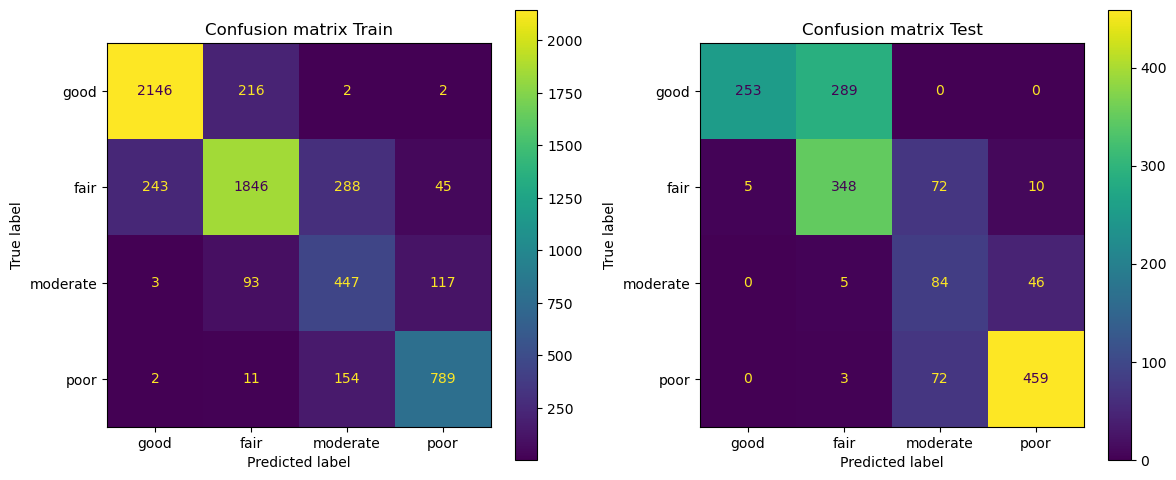

Performance del modello su Train
Accuratezza:    0.81636
Precisione:     0.82881
Recall:         0.81636
F1 score:       0.82028
MCC:            0.73829
---------------------------------------------
Performance del modello su Test
Accuratezza:    0.69502
Precisione:     0.78485
Recall:         0.69502
F1 score:       0.70045
MCC:            0.60370


In [23]:
class_order = ['good', 'fair', 'moderate', 'poor']

fs.display_confusion_matrix_multiclass(model_multiclass, class_order, 'Confusion matrix Train', mmc_X_train, mmc_y_train, title2='Confusion matrix Test', X2=mmc_X_test, y2=mmc_y_test)

print('Performance del modello su Train')
fs.get_performance_param(model_multiclass, mmc_X_train, mmc_y_train, binary=False)
print('---------------------------------------------')
print('Performance del modello su Test')
fs.get_performance_param(model_multiclass, mmc_X_test, mmc_y_test, binary=False)

Vediamo sicuramente dei miglioramenti per quanto riguarda la nuova classe 'poor' che adesso ingloba anche 'very poor'. Tutti i parametri di performance migliorano sia su train che su test. Dalle matrici di confusione notiamo, però, un significativo peggioramento della classificazione della classe 'good', che, seppure venisse predetta erroneamente già più del 50% delle volte, adesso lo sbilanciamento tra predizioni sbagliate e giuste è reso molto più evidente.

Anche provando a cambiare le feature, aggiungendo per esempio gli inquinanti 24 ore prima oppure la media degli inquinanti nelle ore precedenti a quella da studiare, la situazione non sembra migliorare.

Nella logistic regression implementata fino ad ora viene usato in automatico Softmax per la risoluzione del problema multiclasse. Abbiamo provato ad utilizzare invece una strategia OnevsRest per vedere se la situazione migliora, ma anzi, vediamo un netto peggioramento, per cui non riportiamo neanche lo studio.

Per il momento sembra che con i dati ed i mezzi a disposizione non si riescano a fare grandi predizioni su più di due classi. Rimandiamo allo studio della Random Forest la sentenza definitiva.

## Classificazione giornaliera
Per concludere lo studio sulla logistic regression proviamo a rispondere ad una nuova domanda: "riusciamo a prevedere come sarà la qualità dell'aria un certo giorno avendo informazioni su inquinamento, meteo e consumi energetici per i giorni prima?"

La domanda è quindi molto simile a quella precedente, ma lavoriamo con i giorni invece che con le ore. Cambiando in questo modo il problema dobbiamo chiaramente cambiare anche le features e, in generale, lavoreremo con molti meno punti.

Visti i risultati dello studio multiclasse sulle ore, che avevano decisamente più punti, immaginiamo una performance molto peggiore nel caso dei giorni. Per tale motivo ci limitiamo al problema binario 1 = 'ok', 0 = 'not ok', come visto nella prima parte del notebook.

### Importiamo il notebook

In [24]:
daily_class_df = pd.read_csv('../../data/processed/dataset_daily_class_processed.csv')

daily_class_df.head()

,day,cos_week_day,sin_week_day,PM10_mean_1,NO2_mean_1,daily_AQI_1,power_area_50_1,PM10_mean_2,NO2_mean_2,daily_AQI_2,power_area_50_2,PM10_mean_diff_1,NO2_mean_diff_1,daily_AQI_diff_1,PM10_mean_diff_2,NO2_mean_diff_2,daily_AQI_diff_2,temperature,precipitation,target
0,4,1.000000,0.000000,23.652174,18.826087,31.478261,17.478475,28.869565,21.086957,59.058824,18.197335,-5.217391,-2.260870,-27.580563,-2.086957,-0.086957,3.826087,10.796739,0.126087,1
1,5,0.623490,0.781831,14.739130,26.739130,16.695652,37.200400,23.652174,18.826087,31.478261,17.478475,-8.913043,7.913043,-14.782609,-14.130435,5.652174,-42.363171,7.609783,0.028261,1
2,6,-0.222521,0.974928,17.000000,25.913043,23.130435,37.421266,14.739130,26.739130,16.695652,37.200400,2.260870,-0.826087,6.434783,-6.652174,7.086957,-8.347826,9.641304,0.000000,1
3,7,-0.900969,0.433884,14.739130,26.956522,16.521739,35.957377,17.000000,25.913043,23.130435,37.421266,-2.260870,1.043478,-6.608696,0.000000,0.217391,-0.173913,9.980435,0.000000,1
4,8,-0.900969,-0.433884,26.086957,27.260870,32.956522,37.366761,14.739130,26.956522,16.521739,35.957377,11.347826,0.304348,16.434783,9.086957,1.347826,9.826087,8.371739,0.000000,0


### Pipeline
Creiamo la pipeline come fatto precedentemente.

In [25]:
# individuiamo le colonne numeriche e quelle non numeriche
non_num_features = [col for col in daily_class_df.columns if col.startswith('station_')]
num_features = daily_class_df.columns.difference(non_num_features + ['target'])

# per il preprocessing usiamo ColumnTransformer, che permette di trasformare diverse colonne in modo diverso
preprocessor_daily = ColumnTransformer(
    [('num', StandardScaler(), num_features),
     ('one-hot', 'passthrough', non_num_features)])

tscv = TimeSeriesSplit(n_splits=5)

classifier_daily = LogisticRegressionCV(
    Cs=30,                                                          # numero di C = 1/lambda testati
    cv=tscv,                                                        # cv = n => n-fold cross validation
    solver='saga',                                                  # scegliamo saga, che è l'unico che supporta elasticnet
    l1_ratios=[0,0.25,0.5,0.75,1.0],                                # ratei tra l1 e l2 da testare
    scoring=metrics.make_scorer(metrics.matthews_corrcoef),         # usiamo mcc come score perché le classi sono sbilanciate e non abbiamo preferenze tra fpr e fnr
    max_iter=5000,                                                  # numero massimo di iterazioni per l'ottimizzazione
    n_jobs=-1,                                                    # usiamo la massima potenza disponibile nella CPU
    class_weight='balanced',                                        # bilancia in automatico le classi in base alla frequenza di input
    random_state=seed,                                              # per la riproducibilità dei risultati
    use_legacy_attributes=False                                     # uso per evitare warning
)

# costruiamo la nostra pipeline vera e propria
model_daily = Pipeline(steps=[('preprocessor', preprocessor_daily),('classifier', classifier_daily)])

### Train, valid e test + fit

Divido come fatto precedentemente in 70%, 15%, 15%

In [26]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_X_train, day_X_valid, day_X_test, day_y_train, day_y_valid, day_y_test = fs.get_train_valid_test(daily_class_df, 0.7, 0.15, feature_cols)

In [27]:
# contiamo al volo il numeo di punti per ciascuna classe
print(day_y_train.value_counts())
print(day_y_valid.value_counts())
print(day_y_test.value_counts())

target
1    182
0     58
Name: count, dtype: int64
target
0    36
1    18
Name: count, dtype: int64
target
1    41
0     7
Name: count, dtype: int64


È evidente che la diversa proporzione tra le due classi nei diversi insiemi è, nel caso dello studio giornaliero, molto più marcata di quanto non fosse già nello studio orario. Infatti, mediando il valore degli inquinanti sui giorni si perdono le informazioni sulla variabilità oraria, appiattendo tutta l'informazione in un solo dato.\
Con questa distribuzione dei dati, un insieme di validazione sarebbe poco rappresentativo della distribuzione dati su cui è allenato il modello e, pertanto, una ottimizzazione del threshold su questo potrebbe addirittura peggiorare il risultato sul Test.\
Quindi scegliamo di dividere il dataset solo in Train e Test, con una suddivisione 80%/20%.

In [28]:
# splittiamo il dataset e facciamo il fit al modello
feature_cols = list(num_features) + list(non_num_features)

# creiamo train, valid e test
day_X_train, day_X_valid, day_X_test, day_y_train, day_y_valid, day_y_test = fs.get_train_valid_test(daily_class_df, 0.8, 0.0, feature_cols)

In [29]:
# alleniamo il modello sul nostro insieme di training
model_daily.fit(day_X_train,day_y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('one-hot', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

### Importanza delle features

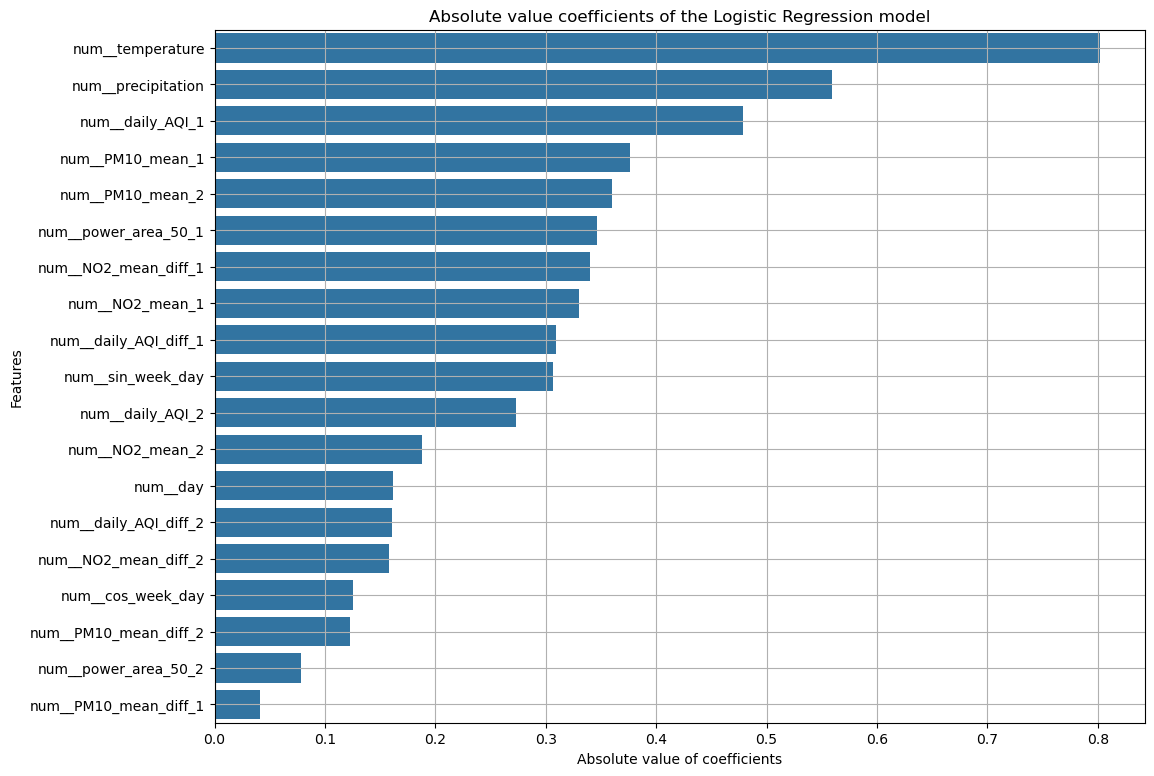

In [30]:
# tiro fuori i nomi delle feature come li ha presi il trasformatore (in questo modo non rischio di scambiare le features)
feature_names = model_daily.named_steps['preprocessor'].get_feature_names_out()

# rappresento il valore assoluto dei coefficienti
fs.display_abs_coefs(model_daily.named_steps['classifier'],feature_names)

Qui osserviamo qualcosa di molto particolare: il valore degli inquinanti di per sé sembra perdere importanza, mentre a guadagnarne sono la temperatura e le precipitazioni, che diventano particolarmente rilevanti. Probabilmente questo risultato è dovuto al fatto che, espandendo l'intervallo di tempo in considerazione, vengono fuori pattern a risposta più lunga, che sono meno rilevanti nel cogliere il rumore ora per ora.

Notiamo come in un primo allenamento avessimo incluso anche le stazioni, ma abbiamo deciso di togliere queste dalle features perché risultavano troppo rilevanti tra i pesi e i risultati erano peggiori. Giustifichiamo questa nostra scelta assumendo che, con così pochi dati, il modello stesse principalmente cogliendo il rumore introdotto dalle stazioni.

### Matrici di confusione per Train e Valid

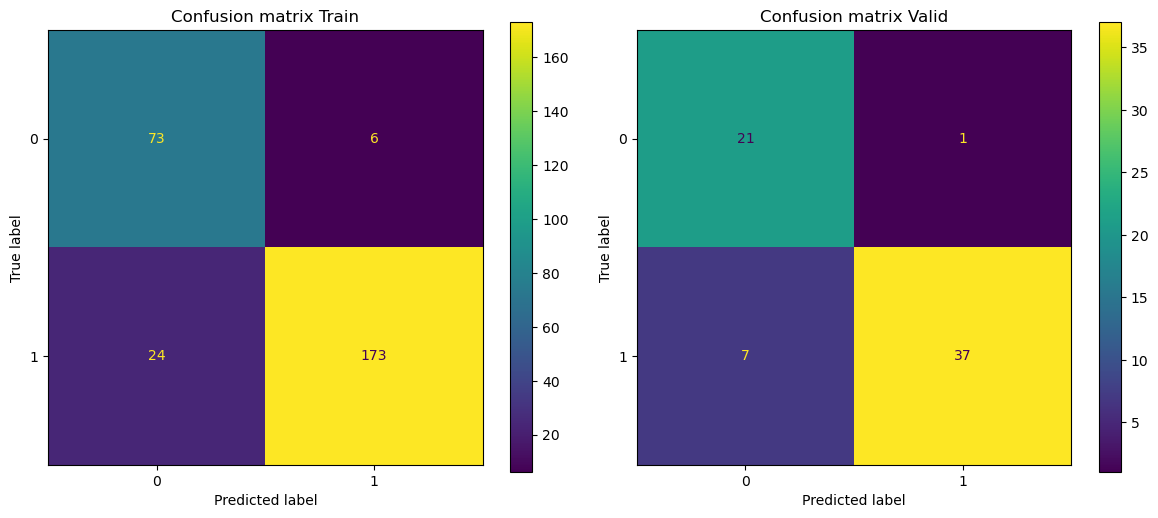

Performance del modello su Train
Accuratezza:    0.89130
Precisione:     0.96648
Recall:         0.87817
F1 score:       0.92021
MCC:            0.75950
---------------------------------------------
Performance del modello su Test
Accuratezza:    0.87879
Precisione:     0.97368
Recall:         0.84091
F1 score:       0.90244
MCC:            0.75872


In [31]:
fs.display_confusion_matrix(model_daily, 'Confusion matrix Train', day_X_train, day_y_train, 'Confusion matrix Valid', day_X_test, day_y_test)

print('Performance del modello su Train')
fs.get_performance_param(model_daily, day_X_train, day_y_train)
print('---------------------------------------------')
print('Performance del modello su Test')
fs.get_performance_param(model_daily, day_X_test, day_y_test)

Come atteso, il modello ha una performance decisamente peggiore rispetto a quello addestrato su base oraria. Questo è causato dal ridotto numero di dati, dalla maggiore disomogeneità tra l'insieme di training e quello di test e dal maggiore intervallo temporale che intercorre tra i dati e la previsione (1 giorno contro 1 ora). Nonostante l'inevitabile peggioramento, giudichiamo comunque la performance sufficiente sulla base dei parametri di performance. 

Rimandiamo allo studio con Random Forest il capire se sia possibile ottenere modelli più predittivi da questo dataframe.